In [8]:
%%html
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@300;400;500;600;700&display=swap" rel="stylesheet">

<style>
/* markdown + output */
body, .markdown-body, .jp-RenderedHTMLCommon, div.text_cell_render,
.notebook, .notebook * {
  font-family: "Source Serif 4", serif !important;
}

/* code editor (monaco) */
.monaco-editor, .monaco-editor * {
  font-family: "Source Serif 4", serif !important;
}
</style>

In [9]:
# one-sample z-test / one-sample t-test

# purpose: compare sample mean against a claim value
# determine if difference is statistically significant

# when to use:
# - z-test: large sample (n >= 30), known population σ
# - t-test: small sample (n < 30), unknown population σ

# formula for test statistic:
# z = (x̄ - μ₀) / (σ / √n)
# t = (x̄ - μ₀) / (s / √n)

# where:
# x̄ = sample mean
# μ₀ = claimed/hypothesized population mean
# σ = population standard deviation (z-test)
# s = sample standard deviation (t-test)
# n = sample size

In [10]:
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t, binom, poisson, expon
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as sswa

In [11]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [12]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'faithful')

In [13]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [14]:
erupt = df.eruptions

In [15]:
# example: test if mean eruption time is at least 3.6 minutes

# claim: mean is at least 3.6
# H₀: μ >= 3.6 (null hypothesis - what we assume is true)
# H₁: μ < 3.6 (alternative - what we want to prove)

# this is a left tail test
# we use one-sample z-test to compare sample mean against claim value 3.6

In [16]:
# One-sample Z-test (test if mean < 3.6)
# Returns (z_statistic, p_value)
z_stat, p_value = sswa.ztest(erupt, value=3.6, alternative='smaller')
print('z-statistic =', z_stat)
print('p-value =', p_value)
# Interpretation:
# H0: population mean >= 3.6
# H1: population mean < 3.6
# For alternative='smaller', p_value = P(Z <= z_stat).
# Small p-value (e.g. < 0.05) => reject H0 in favor of H1 (mean < 3.6).
# Large p-value => insufficient evidence to conclude mean < 3.6.
# Example: if sample mean = 3.48 and the 95% one-sided upper confidence bound is 3.602,
# then 3.6 ≤ 3.602 so the data do not provide strong evidence that the true mean is < 3.6 at α=0.05.

z-statistic = -1.621495827018525
p-value = 0.05245567210775938


In [17]:
# manual calculation of z-statistic
# formula: z = (x̄ - μ₀) / (s / √n)

sample_mean = np.mean(erupt)
claim_value = 3.6
sample_std = np.std(erupt, ddof=1)
n = len(erupt)

z_manual = (sample_mean - claim_value) / (sample_std / n**0.5)
print(f'manual z-statistic = {z_manual:.4f}')

manual z-statistic = -1.6215


In [18]:
# t-critical value for α = 0.05, df = 271 (left tail)
t_crit = t.ppf(0.05, 271)
print(f't-critical value = {t_crit:.4f}')
print(f'if t-statistic < {t_crit:.4f}, reject H₀')

t-critical value = -1.6505
if t-statistic < -1.6505, reject H₀


In [19]:
# z-critical value for α = 0.05 (left tail)
z_crit = norm.ppf(0.05)
print(f'z-critical value = {z_crit:.4f}')

z-critical value = -1.6449


In [20]:
# 95% upper confidence bound (one-sided)
# formula: x̄ + z_critical * (s / √n)

upper_bound = np.mean(erupt) + 1.650495778817526 * np.std(erupt, ddof=1) / len(erupt)**0.5
print(f'95% upper confidence bound = {upper_bound:.4f}')
print(f'sample mean = {np.mean(erupt):.4f}')
print(f'claim value = 3.6')
print(f'\nif claim value <= upper bound, do not reject H₀')

95% upper confidence bound = 3.6020
sample mean = 3.4878
claim value = 3.6

if claim value <= upper bound, do not reject H₀


In [21]:
# right tail test example
# H₀: μ <= claim_value
# H₁: μ > claim_value
# test if mean is significantly greater than claim

In [22]:
# right tail test: is mean > 3.42?
z_stat_right, p_val_right = sswa.ztest(erupt, value=3.42, alternative='larger')
print(f'z-statistic = {z_stat_right:.4f}')
print(f'p-value = {p_val_right:.4f}')
print(f'\nif p-value < 0.05, reject H₀ (mean > 3.42)')

z-statistic = 0.9794
p-value = 0.1637

if p-value < 0.05, reject H₀ (mean > 3.42)


In [23]:
# 95% lower confidence bound (one-sided)
# formula: x̄ - z_critical * (s / √n)

lower_bound = np.mean(erupt) - 1.650495778817526 * np.std(erupt, ddof=1) / len(erupt)**0.5
print(f'95% lower confidence bound = {lower_bound:.4f}')
print(f'sample mean = {np.mean(erupt):.4f}')

95% lower confidence bound = 3.3736
sample mean = 3.4878


In [24]:
# practice example: is population mean > 6?

my_list = [3, 6, 5, 4, 6, 7, 9, 6, 2]

# claim: mean > 6
# H₀: μ <= 6 (null hypothesis)
# H₁: μ > 6 (alternative - we want to prove this)
# this is a right tail test

In [25]:
# note: testing wrong direction here (smaller instead of larger)
# for H₁: μ > 6, should use alternative='larger'
z_stat_wrong, p_val_wrong = sswa.ztest(my_list, value=6, alternative='smaller')
print(f'testing if mean < 6 (wrong direction)')
print(f'z-statistic = {z_stat_wrong:.4f}')
print(f'p-value = {p_val_wrong:.4f}')

testing if mean < 6 (wrong direction)
z-statistic = -0.9428
p-value = 0.1729


In [26]:
# 95% upper confidence bound for my_list
upper_ci = np.mean(my_list) + 1.650495778817526 * np.std(my_list, ddof=1) / len(my_list)**0.5
print(f'95% upper CI bound = {upper_ci:.4f}')

95% upper CI bound = 6.5004


In [27]:
# sample mean of my_list
sample_mean = np.mean(my_list)
print(f'sample mean = {sample_mean:.4f}')
print(f'claim value = 6')
print(f'difference = {sample_mean - 6:.4f}')

sample mean = 5.3333
claim value = 6
difference = -0.6667


In [28]:
# t-critical value for α = 0.05, df = n-1 (right tail)
df = len(my_list) - 1
t_crit_right = t.ppf(0.05, df)
print(f't-critical value (left tail) = {t_crit_right:.4f}')
print(f'for right tail test, use positive value = {-t_crit_right:.4f}')

t-critical value (left tail) = -1.8595
for right tail test, use positive value = 1.8595


In [29]:
# 95% upper confidence bound using t-distribution
t_val = 1.8595480375228428
upper_bound_t = np.mean(my_list) + t_val * np.std(my_list, ddof=1) / len(my_list)**0.5
print(f'95% upper bound = {upper_bound_t:.4f}')
print(f'interpretation: with 95% confidence, true mean <= {upper_bound_t:.4f}')

95% upper bound = 6.6482
interpretation: with 95% confidence, true mean <= 6.6482


In [30]:
# manual t-statistic calculation
# formula: t = (x̄ - μ₀) / (s / √n)

t_manual = (np.mean(my_list) - 6) / (np.std(my_list, ddof=1) / (len(my_list)**0.5))
print(f't-statistic = {t_manual:.4f}')
print(f'interpretation: how many standard errors is sample mean from claimed value?')

t-statistic = -0.9428
interpretation: how many standard errors is sample mean from claimed value?


In [31]:
# p-value using normal distribution
p_norm = norm.cdf(-0.9428090415820639)
print(f'p-value (normal) = {p_norm:.4f}')
print(f'this is P(Z < {-0.9428090415820639:.4f})')

p-value (normal) = 0.1729
this is P(Z < -0.9428)


In [32]:
# p-value using t-distribution (more accurate for small samples)
p_t = t.cdf(-0.9428090415820639, len(my_list) - 1)
print(f'p-value (t-distribution) = {p_t:.4f}')
print(f'df = {len(my_list) - 1}')
print(f'\nfor right tail: p-value = 1 - {p_t:.4f} = {1 - p_t:.4f}')
print(f'since p-value > 0.05, fail to reject H₀')
print(f'conclusion: insufficient evidence that mean > 6')

p-value (t-distribution) = 0.1867
df = 8

for right tail: p-value = 1 - 0.1867 = 0.8133
since p-value > 0.05, fail to reject H₀
conclusion: insufficient evidence that mean > 6


In [33]:
# two-sample z-test / two-sample t-test

# purpose: compare means of two independent samples
# determine if difference between means is statistically significant

# formula for test statistic:
# z = (x̄₁ - x̄₂ - d₀) / SE
# where SE = √(σ₁²/n₁ + σ₂²/n₂)

# for t-test:
# t = (x̄₁ - x̄₂ - d₀) / SE
# where SE = √(s₁²/n₁ + s₂²/n₂)

# d₀ is the claimed difference (often 0)

# use cases:
# - compare treatment vs control groups
# - compare before vs after
# - compare two populations

In [34]:
# example: test if average weight difference is at least 7 kg

# claim: avg(men) - avg(women) >= 7
# H₀: μ_men - μ_women >= 7 (null hypothesis)
# H₁: μ_men - μ_women < 7 (alternative)
# this is a left tail test

In [35]:
males = [76,56,62,65,54,70]
females = [54,57,48,64,57]

In [36]:
# two-sample z-test: is difference < 7?
z_stat_2samp, p_val_2samp = sswa.ztest(males, females, value=7, alternative='smaller')
print(f'sample means:')
print(f'  males: {np.mean(males):.2f} kg')
print(f'  females: {np.mean(females):.2f} kg')
print(f'  difference: {np.mean(males) - np.mean(females):.2f} kg')
print(f'\ntest results:')
print(f'  z-statistic = {z_stat_2samp:.4f}')
print(f'  p-value = {p_val_2samp:.4f}')
print(f'\nif p-value < 0.05, reject H₀ (difference < 7 kg)')

sample means:
  males: 63.83 kg
  females: 56.00 kg
  difference: 7.83 kg

test results:
  z-statistic = 0.1879
  p-value = 0.5745

if p-value < 0.05, reject H₀ (difference < 7 kg)


In [37]:
# actual difference in sample means
diff = np.mean(males) - np.mean(females)
print(f'observed difference = {diff:.2f} kg')
print(f'claimed difference = 7 kg')
print(f'is {diff:.2f} significantly less than 7?')

observed difference = 7.83 kg
claimed difference = 7 kg
is 7.83 significantly less than 7?


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_15027/1351096302.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([males, females], labels=['males', 'females'], patch_artist=True,


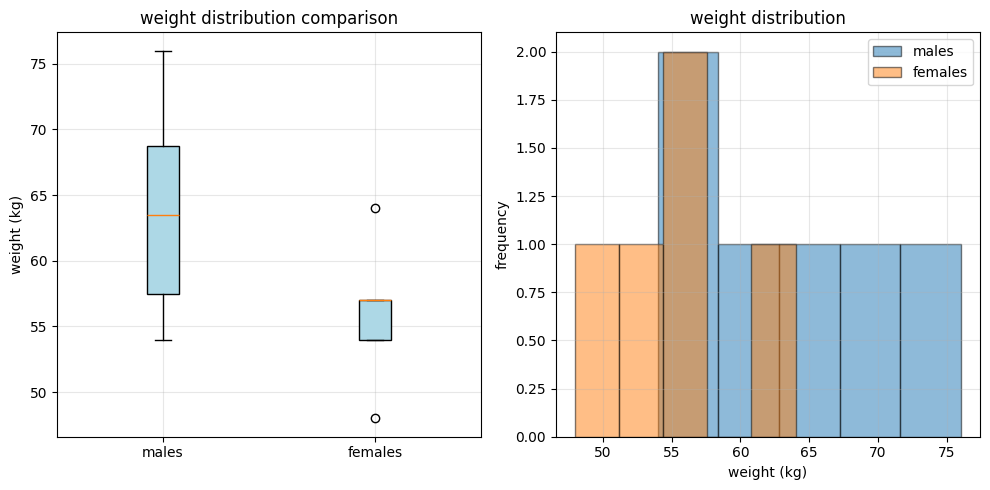


males: mean=63.83, std=8.35
females: mean=56.00, std=5.79


In [38]:
# visualization of two-sample comparison
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# boxplot comparison
plt.subplot(1, 2, 1)
plt.boxplot([males, females], labels=['males', 'females'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.ylabel('weight (kg)')
plt.title('weight distribution comparison')
plt.grid(True, alpha=0.3)

# histogram comparison
plt.subplot(1, 2, 2)
plt.hist(males, alpha=0.5, label='males', bins=5, edgecolor='black')
plt.hist(females, alpha=0.5, label='females', bins=5, edgecolor='black')
plt.xlabel('weight (kg)')
plt.ylabel('frequency')
plt.title('weight distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nmales: mean={np.mean(males):.2f}, std={np.std(males, ddof=1):.2f}')
print(f'females: mean={np.mean(females):.2f}, std={np.std(females, ddof=1):.2f}')

In [39]:
### practice problems — hypothesis testing

# q1. msrtc claims max time to reach kolhapur is 5 hours

# a. null hypothesis:
#    H₀: μ <= 5 (claim — travel time is at most 5 hours)
#    H₁: μ > 5 (right tail test)

# example data
trip = [4.8, 5.2, 6.1, 4.9, 5.5, 5.8, 4.7, 5.3, 6.0, 5.1]

# b. python command and calculation
z_stat_q1, p_val_q1 = sswa.ztest(trip, value=5, alternative='larger')
print('q1: msrtc travel time test')
print(f'sample mean = {np.mean(trip):.2f} hours')
print(f'sample std = {np.std(trip, ddof=1):.2f}')
print(f'z-statistic = {z_stat_q1:.4f}')
print(f'p-value = {p_val_q1:.4f}')

# c. lower confidence bound (one-sided 95%)
alpha = 0.05
t_crit_q1 = t.ppf(1 - alpha, len(trip) - 1)
lower_bound_q1 = np.mean(trip) - t_crit_q1 * np.std(trip, ddof=1) / np.sqrt(len(trip))
print(f'95% lower bound = {lower_bound_q1:.2f} hours')
print(f'decision: lower_bound ({lower_bound_q1:.2f}) > 5? {lower_bound_q1 > 5}')
if p_val_q1 < 0.05:
    print('reject H₀: evidence that mean > 5 hours')
else:
    print('fail to reject H₀: insufficient evidence')
print()

# q2. car manufacturer claims minimum mileage is 18 kmpl

# a. null hypothesis:
#    H₀: μ >= 18 (claim — mileage at least 18 kmpl)
#    H₁: μ < 18 (left tail test)

# example data
mileage = [17.6, 18.2, 17.9, 18.0, 17.4, 17.8, 18.1, 17.5, 17.7, 18.3]

# b. python command and calculation
z_stat_q2, p_val_q2 = sswa.ztest(mileage, value=18, alternative='smaller')
print('q2: car mileage test')
print(f'sample mean = {np.mean(mileage):.2f} kmpl')
print(f'sample std = {np.std(mileage, ddof=1):.2f}')
print(f'z-statistic = {z_stat_q2:.4f}')
print(f'p-value = {p_val_q2:.4f}')

# c. upper confidence bound (one-sided 95%)
t_crit_q2 = t.ppf(1 - alpha, len(mileage) - 1)
upper_bound_q2 = np.mean(mileage) + t_crit_q2 * np.std(mileage, ddof=1) / np.sqrt(len(mileage))
print(f'95% upper bound = {upper_bound_q2:.2f} kmpl')
print(f'decision: upper_bound ({upper_bound_q2:.2f}) < 18? {upper_bound_q2 < 18}')
if p_val_q2 < 0.05:
    print('reject H₀: evidence that mean < 18 kmpl')
else:
    print('fail to reject H₀: insufficient evidence')
print()

# q3. msrtc claims difference with ksrtc is not more than 1 hour

# a. null hypothesis:
#    H₀: μ_msrtc - μ_ksrtc <= 1 (claim — difference at most 1 hour)
#    H₁: μ_msrtc - μ_ksrtc > 1 (right tail test)

# example data
msrtc = [4.2, 3.8, 5.0, 4.5, 4.1, 4.8]
ksrtc = [3.1, 3.4, 3.6, 3.9, 3.2, 3.5]

# b. python command and calculation
z_stat_q3, p_val_q3 = sswa.ztest(msrtc, ksrtc, value=1, alternative='larger')
diff_q3 = np.mean(msrtc) - np.mean(ksrtc)
print('q3: msrtc vs ksrtc travel time difference')
print(f'msrtc mean = {np.mean(msrtc):.2f} hours')
print(f'ksrtc mean = {np.mean(ksrtc):.2f} hours')
print(f'observed difference = {diff_q3:.2f} hours')
print(f'claimed max difference = 1 hour')
print(f'z-statistic = {z_stat_q3:.4f}')
print(f'p-value = {p_val_q3:.4f}')
if p_val_q3 < 0.05:
    print('reject H₀: evidence that difference > 1 hour')
else:
    print('fail to reject H₀: insufficient evidence')
print()

# q4. i claim my students get minimum 10k more salary than ruchi's

# a. null hypothesis:
#    H₀: μ_sudeep - μ_ruchi >= 10 (claim — difference at least 10k)
#    H₁: μ_sudeep - μ_ruchi < 10 (left tail test)

# example data (salaries in thousands)
sudeep = [52, 54, 56, 55, 53, 57, 54, 56]
ruchi = [50, 51, 49, 50, 48, 51, 50, 49]

# b. python command and calculation
z_stat_q4, p_val_q4 = sswa.ztest(sudeep, ruchi, value=10, alternative='smaller')
diff_q4 = np.mean(sudeep) - np.mean(ruchi)
print('q4: sudeep vs ruchi salary difference')
print(f'sudeep mean = {np.mean(sudeep):.2f}k')
print(f'ruchi mean = {np.mean(ruchi):.2f}k')
print(f'observed difference = {diff_q4:.2f}k')
print(f'claimed min difference = 10k')
print(f'z-statistic = {z_stat_q4:.4f}')
print(f'p-value = {p_val_q4:.4f}')
if p_val_q4 < 0.05:
    print('reject H₀: evidence that difference < 10k (claim not supported)')
else:
    print('fail to reject H₀: claim could be true')

q1: msrtc travel time test
sample mean = 5.34 hours
sample std = 0.50
z-statistic = 2.1629
p-value = 0.0153
95% lower bound = 5.05 hours
decision: lower_bound (5.05) > 5? True
reject H₀: evidence that mean > 5 hours

q2: car mileage test
sample mean = 17.85 kmpl
sample std = 0.30
z-statistic = -1.5667
p-value = 0.0586
95% upper bound = 18.03 kmpl
decision: upper_bound (18.03) < 18? False
fail to reject H₀: insufficient evidence

q3: msrtc vs ksrtc travel time difference
msrtc mean = 4.40 hours
ksrtc mean = 3.45 hours
observed difference = 0.95 hours
claimed max difference = 1 hour
z-statistic = -0.2286
p-value = 0.5904
fail to reject H₀: insufficient evidence

q4: sudeep vs ruchi salary difference
sudeep mean = 54.62k
ruchi mean = 49.75k
observed difference = 4.88k
claimed min difference = 10k
z-statistic = -7.3301
p-value = 0.0000
reject H₀: evidence that difference < 10k (claim not supported)


In [40]:
# paired t-test

---

In [41]:
# annova is used when we have more than 1 samples
# this test is used to compare the means of all the pairs of the samples and establish weather they are equal in all cases or not


In [42]:
from statsmodels import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import pandas as pd

In [43]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='faithful')

In [44]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [45]:
erupt = df.eruptions

In [46]:
ts = (len(erupt)-1) * np.var(erupt, ddof = 1)/1.42

In [47]:
ts

np.float64(248.61928042408863)

In [49]:
p_value = chi.cdf(ts, len(erupt))

In [50]:
# ratios of variances of two samples will be compared aagainst two values
# continuity correction

In [ ]:
# you and establish weather the r difference is statistically significant or not
